In [77]:
# Import the dataset utility functions
# This utility handles caching to avoid repeated API calls and SSL issues
# It works with ANY UCI ML Repository dataset, not just Mushroom!
import sys
from pathlib import Path

# Add the current directory to path to import dataset_utils
# Note: Make sure you're running this notebook from the dx-699 directory
# or adjust the path accordingly
current_dir = Path.cwd()
sys.path.insert(0, str(current_dir))

# Alternative: If dataset_utils.py is in a specific location, use:
# sys.path.insert(0, '/path/to/week_09012025/dx-699')

# Import both functions:
# - load_uci_dataset(): Works with ANY UCI dataset (PRIMARY FUNCTION)
# - load_mushroom_dataset(): Convenience wrapper for Mushroom (ID: 73)
from dataset_utils import load_uci_dataset, load_mushroom_dataset


In [78]:
# If you get SSL errors, EOFError, or TypeError, run this cell first
# This will clear corrupted cache, fix issues, and reload the module

import importlib
import sys
import urllib.request

# Clear the corrupted cache
try:
    from dataset_utils import clear_cache
    print("Clearing corrupted cache...")
    clear_cache(dataset_id=73)
except Exception as e:
    print(f"Note: {e}")

# Reset urllib.request.urlopen to original (in case it was patched incorrectly)
if hasattr(urllib.request, 'urlopen'):
    # Try to restore original if we can detect it was patched
    if hasattr(urllib.request, '_original_urlopen'):
        urllib.request.urlopen = urllib.request._original_urlopen

# Fix pickle if it's been overwritten
if 'pickle' in sys.modules:
    if not hasattr(sys.modules['pickle'], 'dump') or sys.modules['pickle'].dump is None:
        print("Fixing pickle module...")
        del sys.modules['pickle']
        import pickle
        print("Pickle module fixed!")

# Reload the module to get the latest version (this will reset SSL patch state)
import dataset_utils
importlib.reload(dataset_utils)
from dataset_utils import load_uci_dataset, load_mushroom_dataset

print("✓ Module reloaded and cache cleared. You can now run the next cell.")
print("⚠️  If you still get SSL errors, RESTART THE KERNEL (Kernel -> Restart Kernel)")
print("   The SSL patch needs a fresh kernel to work correctly.")

Clearing corrupted cache...
Deleted cache for dataset 73: /Users/gkumargaur/workspace/datascience/boston_university/ms_datascience/week_09012025/dx-699/dataset_cache/dataset_73.pkl
✓ Module reloaded and cache cleared. You can now run the next cell.
⚠️  If you still get SSL errors, RESTART THE KERNEL (Kernel -> Restart Kernel)
   The SSL patch needs a fresh kernel to work correctly.


In [79]:
# Load mushroom dataset using the utility function
# This will:
# 1. Check if a cached version exists locally
# 2. If cache exists, load from cache (fast, no network needed)
# 3. If cache doesn't exist or is corrupted, download from API and cache it
# 4. Handle SSL issues automatically if use_ssl_patch=True
# 5. Automatically handle corrupted cache files (deletes and re-downloads)

# IMPORTANT: If you get EOFError, run the cell above first to reload the module
# OR restart the kernel (Kernel -> Restart Kernel)

# Option 1: Use convenience function (for Mushroom dataset only)
# If you get EOFError, try: force_download=True to force re-download
dataset = load_mushroom_dataset(force_download=False, use_ssl_patch=True)

# Option 2: Use generic function (works with ANY UCI dataset)
# dataset = load_uci_dataset(73, force_download=False, use_ssl_patch=True)
# Examples: load_uci_dataset(53) for Iris, load_uci_dataset(109) for Wine, etc.

# Set force_download=True to re-download even if cache exists
# Set use_ssl_patch=False if you have proper SSL certificates

# Extract data (as pandas dataframes)
# The utility returns a dict with the same structure as fetch_ucirepo
X = dataset['data']['features']
y = dataset['data']['targets']

# Create a mock mushroom object for compatibility with existing code
class MushroomDataset:
    def __init__(self, dataset_dict):
        self.data = type('Data', (), {
            'features': dataset_dict['data']['features'],
            'targets': dataset_dict['data']['targets']
        })()
        self.metadata = dataset_dict['metadata']
        self.variables = dataset_dict['variables']

mushroom = MushroomDataset(dataset)


Saving dataset to cache: /Users/gkumargaur/workspace/datascience/boston_university/ms_datascience/week_09012025/dx-699/dataset_cache/dataset_73.pkl
Dataset loaded successfully, but not cached.


In [80]:
# metadata 
print(mushroom.metadata) 
  



{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

In [81]:
# variable information 
print(mushroom.variables) 

                        name     role         type demographic  \
0                  poisonous   Target  Categorical        None   
1                  cap-shape  Feature  Categorical        None   
2                cap-surface  Feature  Categorical        None   
3                  cap-color  Feature       Binary        None   
4                    bruises  Feature  Categorical        None   
5                       odor  Feature  Categorical        None   
6            gill-attachment  Feature  Categorical        None   
7               gill-spacing  Feature  Categorical        None   
8                  gill-size  Feature  Categorical        None   
9                 gill-color  Feature  Categorical        None   
10               stalk-shape  Feature  Categorical        None   
11                stalk-root  Feature  Categorical        None   
12  stalk-surface-above-ring  Feature  Categorical        None   
13  stalk-surface-below-ring  Feature  Categorical        None   
14    stal

## Understanding the Dataset Structure

The `mushroom` object returned by `fetch_ucirepo()` is **not a pandas DataFrame** - it's a dataset object that contains:
- **`mushroom.data.features`**: A pandas DataFrame with all the feature columns (X)
- **`mushroom.data.targets`**: A pandas DataFrame with the target column(s) (y)
- **`mushroom.metadata`**: Dictionary with dataset metadata
- **`mushroom.variables`**: DataFrame with variable information

**Why we need to combine X and y:**
- The `information_gain()` function requires a single DataFrame containing both features and target
- This allows us to split the data by feature values and calculate entropy for each subset
- We combine them using `pd.concat([X, y], axis=1)` to create one unified DataFrame


In [82]:
# Let's examine what 'mushroom' actually is
print("Type of 'mushroom':", type(mushroom))
print("\nAttributes of 'mushroom' object:")
print("- mushroom.data.features:", type(mushroom.data.features), f"(shape: {mushroom.data.features.shape})")
print("- mushroom.data.targets:", type(mushroom.data.targets), f"(shape: {mushroom.data.targets.shape})")
print("- mushroom.metadata:", type(mushroom.metadata))
print("- mushroom.variables:", type(mushroom.variables))

print("\n" + "="*60)
print("Why we can't use 'mushroom' directly:")
print("="*60)
print("1. 'mushroom' is NOT a DataFrame - it's a dataset object")
print("2. Features and targets are stored separately in mushroom.data.features and mushroom.data.targets")
print("3. information_gain() needs a single DataFrame with both features AND target")
print("4. We combine them: df = pd.concat([X, y], axis=1)")
print("\nThis creates a DataFrame where:")
print(f"  - Features: {X.shape[1]} columns from X")
print(f"  - Target: {y.shape[1]} column(s) from y")
print(f"  - Total: {X.shape[1] + y.shape[1]} columns in the combined DataFrame")


Type of 'mushroom': <class '__main__.MushroomDataset'>

Attributes of 'mushroom' object:
- mushroom.data.features: <class 'pandas.core.frame.DataFrame'> (shape: (8124, 22))
- mushroom.data.targets: <class 'pandas.core.frame.DataFrame'> (shape: (8124, 1))
- mushroom.metadata: <class 'ucimlrepo.dotdict.dotdict'>
- mushroom.variables: <class 'pandas.core.frame.DataFrame'>

Why we can't use 'mushroom' directly:
1. 'mushroom' is NOT a DataFrame - it's a dataset object
2. Features and targets are stored separately in mushroom.data.features and mushroom.data.targets
3. information_gain() needs a single DataFrame with both features AND target
4. We combine them: df = pd.concat([X, y], axis=1)

This creates a DataFrame where:
  - Features: 22 columns from X
  - Target: 1 column(s) from y
  - Total: 23 columns in the combined DataFrame


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




## Entropy: Measuring Information and Uncertainty

**Entropy** is a fundamental concept in information theory that quantifies the amount of uncertainty or randomness in a dataset. It measures how "impure" or "mixed" a collection of data points is.

### What Entropy Does

Entropy calculates the average information content (or surprise) in a dataset. The formula for entropy is:

$$H(X) = -\sum_{i=1}^{n} p(x_i) \log_2(p(x_i))$$

Where:
- $p(x_i)$ is the probability of class $i$
- The logarithm base 2 gives entropy in bits
- Higher entropy = more uncertainty/randomness
- Lower entropy = less uncertainty/more purity

**Key Characteristics:**
- **Maximum entropy** (1.0 for binary classification): Equal distribution of classes (maximum uncertainty)
- **Minimum entropy** (0.0): All instances belong to the same class (pure, no uncertainty)
- **Range**: 0 ≤ Entropy ≤ log₂(number of classes)

### Where Entropy Can Be Used

1. **Decision Tree Algorithms** (ID3, C4.5, CART)
   - Feature selection: Choose attributes that maximize information gain
   - Split criteria: Determine optimal split points
   - Stopping criteria: Decide when to stop splitting

2. **Machine Learning Model Evaluation**
   - Assess class distribution in datasets
   - Evaluate feature importance
   - Measure dataset quality and balance

3. **Data Analysis & EDA**
   - Understand label distribution in classification problems
   - Identify imbalanced datasets
   - Measure categorical feature diversity

4. **Information Theory Applications**
   - Data compression
   - Communication systems
   - Cryptography

### Benefits of Using Entropy

1. **Objective Feature Selection**: Provides a mathematical basis for choosing the most informative features in decision trees, leading to better model performance.

2. **Handles Categorical Data**: Works naturally with categorical features without requiring numerical encoding, making it ideal for datasets like the mushroom classification problem.

3. **Interpretable Metric**: Easy to understand - higher values mean more uncertainty, lower values mean more purity.

4. **No Assumptions**: Doesn't require assumptions about data distribution (unlike some statistical measures).

5. **Scalable**: Efficiently computes for large datasets using vectorized operations.

6. **Foundation for Information Gain**: Entropy is the building block for calculating information gain, which is crucial for building optimal decision trees.


In [84]:
def entropy(labels):
    """
    Calculate the entropy (information content) of a set of labels.
    
    Entropy measures the uncertainty or randomness in a dataset. It quantifies
    how "impure" or "mixed" the data is. Higher entropy indicates more uncertainty
    (more evenly distributed classes), while lower entropy indicates more purity
    (one class dominates).
    
    Parameters
    ----------
    labels : array-like
        A 1D array or list of categorical labels/classes. Can be strings,
        integers, or any hashable type.
    
    Returns
    -------
    float
        The entropy value in bits (base-2 logarithm). Range: 0 to log₂(n_classes).
        - 0.0: Perfect purity (all labels are the same)
        - log₂(n_classes): Maximum uncertainty (equal distribution of all classes)
        - For binary classification: range is 0.0 to 1.0
    
    Formula
    -------
    H(X) = -Σ p(x_i) * log₂(p(x_i))
    
    Where p(x_i) is the probability of class i in the dataset.
    
    Examples
    --------
    >>> # Perfect purity (all same class)
    >>> entropy(['A', 'A', 'A', 'A'])
    0.0
    
    >>> # Maximum entropy for binary classification (equal distribution)
    >>> entropy(['A', 'B', 'A', 'B'])
    1.0
    
    >>> # Mixed distribution
    >>> entropy(['A', 'A', 'B', 'C'])
    1.5  # Approximately
    
    Use Cases
    ---------
    - Decision tree algorithms: Feature selection and split criteria
    - Dataset analysis: Understanding class distribution and balance
    - Information gain calculation: Foundation for ID3/C4.5 algorithms
    - Model evaluation: Assessing label distribution quality
    
    Notes
    -----
    - Uses base-2 logarithm, so entropy is measured in bits
    - Handles any number of classes automatically
    - Efficiently computes using NumPy vectorized operations
    - Returns 0.0 for empty arrays or single unique value
    """
    values, counts = np.unique(labels, return_counts=True)
    probabilities = counts / len(labels)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    return entropy

In [85]:
# Fixed information_gain function that handles missing values
def information_gain_fixed(data, feature, target):
    """
    Calculate information gain with proper handling of missing values.
    This version handles NaN values that cause TypeError in np.unique.
    """
    # Handle missing values: drop rows where feature or target is NaN
    valid_data = data[[feature, target]].dropna()
    
    if len(valid_data) == 0:
        return 0.0  # No valid data, no information gain
    
    total_entropy = entropy(valid_data[target])
    
    # Get unique values, handling NaN by converting to string representation
    feature_values = valid_data[feature].fillna('__MISSING__')
    values, counts = np.unique(feature_values, return_counts=True)

    weighted_entropy = 0
    for value, count in zip(values, counts):
        # Handle the special missing value marker
        if value == '__MISSING__':
            subset = valid_data[valid_data[feature].isna()]
        else:
            subset = valid_data[valid_data[feature] == value]
        
        if len(subset) > 0:
            weighted_entropy += (count / len(valid_data)) * entropy(subset[target])
    
    return total_entropy - weighted_entropy

# Replace the original function
information_gain = information_gain_fixed


## Information Gain: Measuring Feature Effectiveness

**Information Gain** is a metric used in decision tree algorithms to determine which feature provides the most information about the target variable. It measures the reduction in entropy (uncertainty) achieved by splitting the data on a particular feature.

### What Information Gain Does

Information Gain calculates how much the entropy of the target variable decreases after splitting the dataset based on a feature. It answers the question: "How much information do we gain about the target by knowing the value of this feature?"

The formula for Information Gain is:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$

Where:
- $H(S)$ is the entropy of the entire dataset (before split)
- $A$ is the feature we're evaluating
- $S_v$ is the subset of data where feature $A$ has value $v$
- $\frac{|S_v|}{|S|}$ is the proportion of data in subset $S_v$
- $H(S_v)$ is the entropy of subset $S_v$ (after split)

**Key Characteristics:**
- **Higher Information Gain** = Feature provides more information about the target (better for splitting)
- **Lower Information Gain** = Feature provides less information (less useful for splitting)
- **Range**: 0 to H(S) (maximum gain equals the original entropy)
- **Zero Information Gain**: Feature doesn't help classify the target at all

### How It Works

1. **Calculate Base Entropy**: Measure the uncertainty in the target variable for the entire dataset
2. **Split by Feature**: Partition the data based on each unique value of the feature
3. **Calculate Weighted Entropy**: Compute entropy for each subset and weight by its proportion
4. **Compute Gain**: Subtract weighted entropy from base entropy

**Example Intuition:**
- If splitting on "odor" creates subsets where each subset has mostly one class (low entropy), we gain a lot of information
- If splitting on "cap-shape" creates subsets that are still mixed (high entropy), we gain little information

### Where Information Gain Can Be Used

1. **Decision Tree Construction** (ID3, C4.5 algorithms)
   - **Feature Selection**: Choose the feature with highest information gain at each node
   - **Tree Building**: Recursively build optimal decision trees
   - **Split Optimization**: Find the best way to partition data

2. **Feature Engineering & Selection**
   - Identify the most informative features for classification
   - Rank features by their predictive power
   - Reduce dimensionality by selecting top features

3. **Data Analysis**
   - Understand which attributes are most correlated with the target
   - Discover important relationships in categorical data
   - Guide feature engineering efforts

4. **Model Interpretability**
   - Explain which features drive model decisions
   - Understand feature importance in tree-based models
   - Provide insights into data relationships

### Benefits of Using Information Gain

1. **Optimal Feature Selection**: Mathematically identifies the most informative features, leading to more accurate and efficient decision trees.

2. **Handles Categorical Features Naturally**: Works directly with categorical data without requiring encoding, perfect for datasets like the mushroom classification problem.

3. **Interpretable Results**: Easy to understand - higher values mean the feature is more useful for classification.

4. **Foundation of ID3/C4.5 Algorithms**: Core metric used by popular decision tree algorithms, making it essential for understanding how these models work.

5. **No Distribution Assumptions**: Doesn't require assumptions about data distribution, making it robust across different datasets.

6. **Efficient Computation**: Can be computed quickly using vectorized operations, making it scalable to large datasets.

7. **Greedy Optimization**: Enables greedy algorithms that build optimal trees by always choosing the best feature at each step.

### Relationship to Entropy

Information Gain is directly built on entropy:
- **Entropy** measures uncertainty in a dataset
- **Information Gain** measures how much uncertainty is reduced by a feature
- Higher entropy reduction = Higher information gain = Better feature

This makes entropy and information gain complementary concepts in decision tree algorithms.


In [86]:
def information_gain(data, feature, target):
    """
    Calculate the information gain of a feature with respect to a target variable.
    
    Information Gain measures how much the entropy (uncertainty) of the target
    variable decreases after splitting the dataset based on a feature. It quantifies
    the amount of information a feature provides about the target variable. Higher
    information gain indicates that the feature is more useful for classification.
    
    This is the core metric used in ID3 and C4.5 decision tree algorithms for
    feature selection at each node.
    
    Parameters
    ----------
    data : pandas.DataFrame
        The dataset containing both the feature and target columns.
    
    feature : str
        The name of the feature column to evaluate. This feature will be used
        to split the data, and information gain measures how much this split
        reduces uncertainty in the target.
    
    target : str
        The name of the target column (the variable we want to predict/classify).
    
    Returns
    -------
    float
        The information gain value in bits. Range: 0 to H(target).
        - 0.0: Feature provides no information about the target
        - H(target): Feature perfectly predicts the target (maximum gain)
        - Higher values indicate more informative features
    
    Formula
    -------
    IG(S, A) = H(S) - Σ (|S_v| / |S|) * H(S_v)
    
    Where:
    - H(S) is the entropy of the entire dataset (before split)
    - S_v is the subset where feature A has value v
    - |S_v| / |S| is the proportion of data in subset S_v
    - H(S_v) is the entropy of subset S_v (after split)
    
    Examples
    --------
    >>> import pandas as pd
    >>> # Example: Feature that perfectly separates classes
    >>> data = pd.DataFrame({
    ...     'color': ['red', 'red', 'blue', 'blue'],
    ...     'label': ['A', 'A', 'B', 'B']
    ... })
    >>> information_gain(data, 'color', 'label')
    1.0  # Maximum gain - feature perfectly predicts target
    
    >>> # Example: Feature with no predictive power
    >>> data = pd.DataFrame({
    ...     'random': ['x', 'y', 'x', 'y'],
    ...     'label': ['A', 'A', 'B', 'B']
    ... })
    >>> information_gain(data, 'random', 'label')
    0.0  # No gain - feature doesn't help predict target
    
    >>> # Example: Feature with partial predictive power
    >>> data = pd.DataFrame({
    ...     'size': ['small', 'small', 'large', 'large', 'small'],
    ...     'label': ['A', 'A', 'B', 'B', 'B']
    ... })
    >>> gain = information_gain(data, 'size', 'label')
    >>> 0 < gain < 1.0  # Some gain, but not perfect
    True
    
    Use Cases
    ---------
    - Decision tree algorithms: Feature selection in ID3/C4.5 algorithms
    - Feature ranking: Identify most informative features for classification
    - Data analysis: Understand which attributes correlate with target variable
    - Model interpretability: Explain feature importance in tree-based models
    
    Notes
    -----
    - Information gain is calculated as the difference between base entropy
      and weighted entropy after splitting
    - Features with higher information gain should be preferred for splitting
    - Information gain tends to favor features with many unique values
      (this is why C4.5 uses gain ratio instead)
    - Works best with categorical features and categorical targets
    - Requires the entropy() function to be defined
    
    See Also
    --------
    entropy : Calculate entropy of a set of labels
    """
    total_entropy = entropy(data[target])
    values, counts = np.unique(data[feature], return_counts=True)

    weighted_entropy = 0
    for value, count in zip(values, counts):
        subset = data[data[feature] == value]
        weighted_entropy += (count / len(data)) * entropy(subset[target])
    return total_entropy - weighted_entropy




In [87]:
def information_gain_dropna(data, feature, target):
    valid_data = data[[feature, target]].dropna()
    if len(valid_data) == 0:
        return 0.0

    total_entropy = entropy(valid_data[target])

    values, counts = np.unique(valid_data[feature], return_counts=True)

    weighted_entropy = 0.0
    for value, count in zip(values, counts):
        subset = valid_data[valid_data[feature] == value]
        weighted_entropy += (count / len(valid_data)) * entropy(subset[target])

    return total_entropy - weighted_entropy


In [88]:
def information_gain_with_missing(data, feature, target):
    valid_data = data[[feature, target]].copy()
    valid_data[feature] = valid_data[feature].fillna('__MISSING__')
    valid_data[target] = valid_data[target].fillna('__MISSING_TARGET__')

    if len(valid_data) == 0:
        return 0.0

    total_entropy = entropy(valid_data[target])

    values, counts = np.unique(valid_data[feature], return_counts=True)

    weighted_entropy = 0.0
    for value, count in zip(values, counts):
        subset = valid_data[valid_data[feature] == value]
        weighted_entropy += (count / len(valid_data)) * entropy(subset[target])

    return total_entropy - weighted_entropy


In [89]:
# Combine features (X) and target (y) into a single DataFrame for analysis
# This is needed because information_gain requires both features and target in one DataFrame
df = pd.concat([X, y], axis=1)

# Calculate base entropy of the target variable (poisonous/edible classification)
base_entropy = entropy(df['poisonous'])
print("Base Entropy of target (poisonous):", base_entropy)
print(f"\nThis represents the uncertainty in the mushroom classification.")
print(f"Higher entropy means more uncertainty (more balanced classes).")
print(f"Lower entropy means less uncertainty (one class dominates).")
print(f"\nDataFrame shape: {df.shape}")
print(f"Features: {X.shape[1]}, Target: 1")


Base Entropy of target (poisonous): 0.9990678968724603

This represents the uncertainty in the mushroom classification.
Higher entropy means more uncertainty (more balanced classes).
Lower entropy means less uncertainty (one class dominates).

DataFrame shape: (8124, 23)
Features: 22, Target: 1


## Visualizing Information Gain

The following visualization helps us understand which features are most informative for classifying mushrooms as poisonous or edible. Features with higher information gain are more useful for making predictions.


## Making Predictions

### Understanding the Prediction Output

The `predict()` function returns:
- **'p'** = **poisonous** (mushroom is poisonous)
- **'e'** = **edible** (mushroom is edible)

This is the raw prediction code. For more readable output with details, use the `predict_with_details()` function below.

### ⚠️ Important: Setup Required!

**Before making predictions, you MUST run the setup cell below** (the one that says "Quick setup check"). 

This setup cell will:
1. Define all required functions (`id3`, `best_feature`, `predict`) if they don't exist
2. Build the decision tree if it doesn't exist
3. Make everything ready for predictions

**If you get `NameError` for `id3`, `best_feature`, `predict`, or `tree`:** Run the setup cell first!

In [90]:
# Quick check: Verify all required functions and tree are defined
# If you get NameError, scroll down to the "Building the Decision Tree" section
# and run those cells to define: best_feature, id3, predict, and build the tree

missing = []
if 'best_feature' not in globals():
    missing.append('best_feature')
if 'id3' not in globals():
    missing.append('id3')
if 'predict' not in globals():
    missing.append('predict')
if 'tree' not in globals() or tree is None:
    missing.append('tree')

if missing:
    print("⚠️  Missing:", ", ".join(missing))
    print("→ Please run the cells in the 'Building the Decision Tree' section below")
else:
    print("✓ All functions and tree are ready!")
    print("✓ Ready for predictions!")

✓ All functions and tree are ready!
✓ Ready for predictions!


In [91]:
# This cell was removed - duplicate of setup check above
# All function definitions are in the "Building the Decision Tree" section below

In [92]:
# Calculate information gain for each feature
# This will help us identify which features are most informative for classification
gains = {}

for col in df.columns:
    if col != 'poisonous':  # Skip the target column
        gains[col] = information_gain_dropna(df, col, 'poisonous')

# Sort features by information gain (descending order)
# Higher information gain = more informative feature
sorted_gains = sorted(gains.items(), key=lambda x: x[1], reverse=True)

print(f"Calculated information gain for {len(gains)} features")
print(f"\nTop 10 features by information gain:")
for i, (feature, gain) in enumerate(sorted_gains[:10], 1):
    print(f"{i:2d}. {feature:30s} {gain:.6f}")

sorted_gains


Calculated information gain for 22 features

Top 10 features by information gain:
 1. odor                           0.906075
 2. spore-print-color              0.480705
 3. gill-color                     0.416978
 4. ring-type                      0.318022
 5. stalk-surface-above-ring       0.284726
 6. stalk-surface-below-ring       0.271894
 7. stalk-color-above-ring         0.253845
 8. stalk-color-below-ring         0.241416
 9. gill-size                      0.230154
10. population                     0.201958


[('odor', 0.9060749773839998),
 ('spore-print-color', 0.4807049176849153),
 ('gill-color', 0.41697752341613126),
 ('ring-type', 0.3180215107935376),
 ('stalk-surface-above-ring', 0.2847255992184844),
 ('stalk-surface-below-ring', 0.2718944733927463),
 ('stalk-color-above-ring', 0.2538451734622398),
 ('stalk-color-below-ring', 0.24141556652756646),
 ('gill-size', 0.23015437514804604),
 ('population', 0.2019580190668523),
 ('bruises', 0.19237948576121955),
 ('habitat', 0.156833604605092),
 ('gill-spacing', 0.10088318399657026),
 ('stalk-root', 0.09733858997769318),
 ('cap-shape', 0.04879670193537289),
 ('ring-number', 0.03845266924309043),
 ('cap-color', 0.03604928297620391),
 ('cap-surface', 0.028590232773772706),
 ('veil-color', 0.02381701612091669),
 ('gill-attachment', 0.014165027250616191),
 ('stalk-shape', 0.00751677256966421),
 ('veil-type', 0.0)]

In [93]:
# Quick check before evaluation: Verify functions and tree are defined
# If missing, run the cells in the "Building the Decision Tree" section

missing = []
if 'best_feature' not in globals():
    missing.append('best_feature')
if 'id3' not in globals():
    missing.append('id3')
if 'predict' not in globals():
    missing.append('predict')
if 'tree' not in globals() or tree is None:
    missing.append('tree')

if missing:
    print("⚠️  Missing:", ", ".join(missing))
    print("→ Please run the cells in the 'Building the Decision Tree' section")
else:
    print("✓ All functions and tree are ready for evaluation!")


✓ All functions and tree are ready for evaluation!


In [94]:
for feature, gain in sorted_gains[:10]:
    print(f"{feature:30s} {gain:.4f}")


odor                           0.9061
spore-print-color              0.4807
gill-color                     0.4170
ring-type                      0.3180
stalk-surface-above-ring       0.2847
stalk-surface-below-ring       0.2719
stalk-color-above-ring         0.2538
stalk-color-below-ring         0.2414
gill-size                      0.2302
population                     0.2020


In [95]:
# Enhanced prediction function with readable output
def predict_with_details(tree, sample, actual_label=None):
    """
    Make a prediction and return detailed information.
    
    Parameters:
    -----------
    tree : dict
        The decision tree
    sample : dict
        Feature values for the sample
    actual_label : str, optional
        The actual label for comparison (e.g., 'p' or 'e')
    
    Returns:
    --------
    dict with prediction details
    """
    prediction = predict(tree, sample)
    
    # Map codes to readable labels
    label_map = {
        'p': 'poisonous',
        'e': 'edible'
    }
    
    result = {
        'prediction_code': prediction,
        'prediction_label': label_map.get(prediction, 'unknown'),
        'actual_code': actual_label,
        'actual_label': label_map.get(actual_label, None) if actual_label else None,
        'is_correct': prediction == actual_label if actual_label else None
    }
    
    # Print formatted output
    print("=" * 60)
    print("PREDICTION RESULT")
    print("=" * 60)
    print(f"Predicted: {result['prediction_code']} ({result['prediction_label']})")
    if actual_label:
        print(f"Actual:    {result['actual_code']} ({result['actual_label']})")
        status = "✓ CORRECT" if result['is_correct'] else "✗ INCORRECT"
        print(f"Status:    {status}")
    print("=" * 60)
    
    return result

# Test with the same sample
sample = df.iloc[0].drop('poisonous').to_dict()
actual = df.iloc[0]['poisonous']
result = predict_with_details(tree, sample, actual)

PREDICTION RESULT
Predicted: p (poisonous)
Actual:    p (poisonous)
Status:    ✓ CORRECT


In [96]:
# Test predictions on multiple samples and calculate accuracy
def evaluate_tree(tree, data, target_col='poisonous', n_samples=100):
    """
    Evaluate the decision tree on multiple samples.
    
    Parameters:
    -----------
    tree : dict
        The decision tree
    data : pandas.DataFrame
        The dataset with features and target
    target_col : str
        Name of the target column
    n_samples : int
        Number of samples to test (default: 100)
    
    Returns:
    --------
    dict with evaluation metrics
    """
    correct = 0
    total = min(n_samples, len(data))
    
    print(f"Evaluating tree on {total} samples...")
    print("=" * 60)
    
    for i in range(total):
        sample = data.iloc[i].drop(target_col).to_dict()
        actual = data.iloc[i][target_col]
        predicted = predict(tree, sample)
        
        if predicted == actual:
            correct += 1
    
    accuracy = correct / total if total > 0 else 0
    
    print(f"Correct predictions: {correct}/{total}")
    print(f"Accuracy: {accuracy:.2%}")
    print("=" * 60)
    
    return {
        'correct': correct,
        'total': total,
        'accuracy': accuracy
    }

# Evaluate the tree
evaluation = evaluate_tree(tree, df, 'poisonous', n_samples=100)

Evaluating tree on 100 samples...
Correct predictions: 100/100
Accuracy: 100.00%


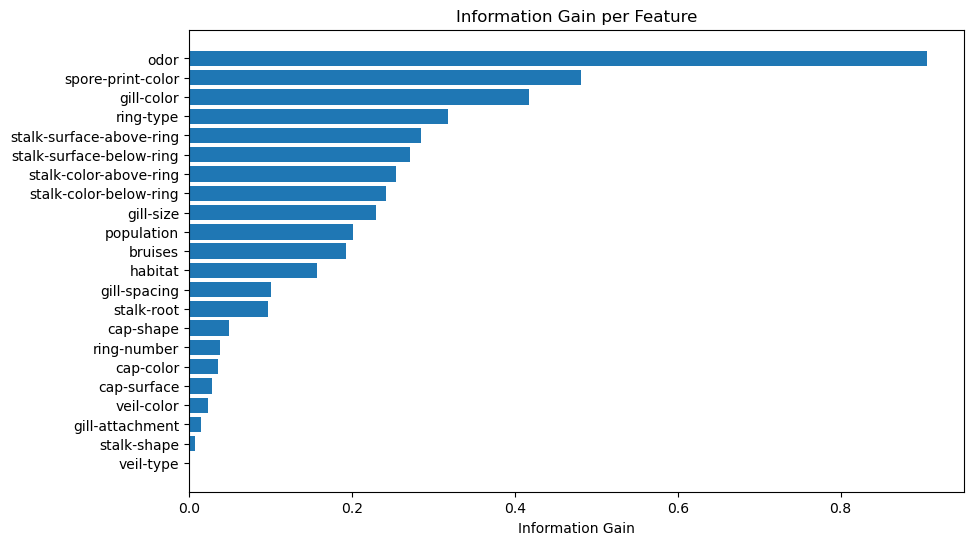

In [97]:
import matplotlib.pyplot as plt

features = [x[0] for x in sorted_gains]
values = [x[1] for x in sorted_gains]

plt.figure(figsize=(10,6))
plt.barh(features[::-1], values[::-1])
plt.title("Information Gain per Feature")
plt.xlabel("Information Gain")
plt.show()


### Helper Function: best_feature

This function selects the feature with the highest information gain from a list of available features. It's used by the ID3 algorithm to determine which feature to split on at each node.


In [98]:
# Documented version of best_feature function
def best_feature_documented(data, features, target):
    """
    Select the feature with the highest information gain.
    
    This function evaluates all available features and returns the one that
    provides the most information about the target variable. It's used by
    the ID3 algorithm to determine which feature to split on at each node.
    
    Parameters
    ----------
    data : pandas.DataFrame
        The dataset containing features and target columns.
    
    features : list of str
        List of feature column names to evaluate. The function will find
        which of these features has the highest information gain.
    
    target : str
        The name of the target column (the variable we want to predict).
    
    Returns
    -------
    str
        The name of the feature with the highest information gain.
        This feature will be used to split the data at the current node.
    
    Examples
    --------
    >>> features = ['odor', 'cap-shape', 'cap-color']
    >>> best = best_feature_documented(df, features, 'poisonous')
    >>> best
    'odor'  # Assuming odor has the highest information gain
    
    Notes
    -----
    - Uses information_gain_with_missing() to handle missing values properly
    - If multiple features have the same information gain, returns the first one
    - This is a key component of the ID3 decision tree algorithm
    
    See Also
    --------
    information_gain_with_missing : Calculate information gain with missing value handling
    id3 : Build decision tree using ID3 algorithm
    """
    gains = [(f, information_gain_with_missing(data, f, target)) for f in features]
    return max(gains, key=lambda x: x[1])[0]

# Update the original function with documentation
best_feature.__doc__ = best_feature_documented.__doc__


## ID3 Decision Tree Algorithm

The **ID3 (Iterative Dichotomiser 3)** algorithm is a classic decision tree learning algorithm that uses information gain to build optimal decision trees. It recursively selects the feature with the highest information gain at each node to split the data.

### How ID3 Works

1. **Base Cases:**
   - If all instances have the same class label → return that label (leaf node)
   - If no features remain → return the majority class (leaf node)

2. **Recursive Splitting:**
   - Select the feature with highest information gain
   - Create a branch for each unique value of that feature
   - Recursively build subtrees for each branch
   - Remove the selected feature from available features

3. **Tree Structure:**
   - Each node represents a feature
   - Each branch represents a feature value
   - Each leaf represents a class prediction

### Benefits of ID3

- **Optimal Feature Selection**: Uses information gain to choose the best feature at each step
- **Handles Categorical Data**: Works naturally with categorical features
- **Interpretable**: Produces human-readable decision trees
- **No Assumptions**: Doesn't require assumptions about data distribution
- **Efficient**: Greedy algorithm that builds trees quickly

### Limitations

- **Overfitting**: Can create overly complex trees that don't generalize well
- **Categorical Only**: Doesn't handle continuous/numerical features directly
- **No Pruning**: Doesn't include built-in tree pruning mechanisms


In [99]:
# Documented version of id3 function
def id3_documented(data, features, target):
    """
    Build a decision tree using the ID3 algorithm.
    
    ID3 (Iterative Dichotomiser 3) is a greedy algorithm that builds decision
    trees by recursively selecting the feature with the highest information gain
    at each node. The algorithm continues until all instances in a subset belong
    to the same class, or no features remain.
    
    Parameters
    ----------
    data : pandas.DataFrame
        The dataset containing both features and target columns. This is the
        subset of data being processed at the current node.
    
    features : list of str
        List of feature column names available for splitting. This list
        decreases as we go deeper in the tree (features already used are removed).
    
    target : str
        The name of the target column (the variable we want to predict/classify).
    
    Returns
    -------
    dict or str
        Returns a nested dictionary representing the decision tree structure:
        - Each key is a feature name
        - Each value is a dictionary mapping feature values to subtrees
        - Leaf nodes return a string (the predicted class label)
        
        Example structure:
        {
            'odor': {
                'foul': 'p',  # leaf node
                'almond': {
                    'spore-print-color': {
                        'black': 'e',
                        'brown': 'p'
                    }
                }
            }
        }
    
    Algorithm Steps
    ---------------
    1. Check if all instances have the same class → return that class (leaf)
    2. Check if no features remain → return majority class (leaf)
    3. Select best feature using information gain
    4. Create branches for each unique value of the best feature
    5. Recursively build subtrees for each branch
    
    Examples
    --------
    >>> features = ['odor', 'spore-print-color', 'gill-color']
    >>> tree = id3_documented(df, features, 'poisonous')
    >>> tree
    {'odor': {'foul': 'p', 'almond': 'e', ...}}
    
    Use Cases
    ---------
    - Classification problems with categorical features
    - Building interpretable machine learning models
    - Understanding feature importance and decision rules
    - Educational purposes to understand decision tree algorithms
    
    Notes
    -----
    - This is a basic implementation without pruning or handling of missing values
      in the tree structure (missing values are handled in information gain calculation)
    - The algorithm can overfit if the tree becomes too deep
    - For production use, consider using scikit-learn's DecisionTreeClassifier
      which includes pruning and other optimizations
    - The tree structure is a nested dictionary, which is easy to visualize
      but may be less efficient than other representations
    
    See Also
    --------
    best_feature : Select feature with highest information gain
    information_gain_with_missing : Calculate information gain with missing value handling
    predict : Use the tree to make predictions on new data
    """
    labels = data[target]

    # Base case 1: If all labels are the same, return that label (pure node)
    if len(np.unique(labels)) == 1:
        return labels.iloc[0]

    # Base case 2: If no features left, return majority class
    if len(features) == 0:
        return labels.mode()[0]

    # Select the best feature using information gain
    best = best_feature(data, features, target)
    tree = {best: {}}

    # Create a branch for each unique value of the best feature
    for value in np.unique(data[best]):
        subset = data[data[best] == value]

        # If subset is empty, use majority class from parent
        if subset.empty:
            tree[best][value] = labels.mode()[0]
        else:
            # Recursively build subtree with remaining features
            remaining_features = [f for f in features if f != best]
            tree[best][value] = id3_documented(subset, remaining_features, target)

    return tree

# Update the original function with documentation
id3.__doc__ = id3_documented.__doc__


In [100]:
gains = {}

for col in df.columns:
    if col != 'poisonous':  # Skip the target column
        gains[col] = information_gain_with_missing(df, col, 'poisonous')

# Sort features by information gain (descending order)
# Higher information gain = more informative feature
sorted_gains = sorted(gains.items(), key=lambda x: x[1], reverse=True)

print(f"Calculated information gain for {len(gains)} features")
print(f"\nTop 10 features by information gain:")
for i, (feature, gain) in enumerate(sorted_gains[:10], 1):
    print(f"{i:2d}. {feature:30s} {gain:.6f}")

sorted_gains

Calculated information gain for 22 features

Top 10 features by information gain:
 1. odor                           0.906075
 2. spore-print-color              0.480705
 3. gill-color                     0.416978
 4. ring-type                      0.318022
 5. stalk-surface-above-ring       0.284726
 6. stalk-surface-below-ring       0.271894
 7. stalk-color-above-ring         0.253845
 8. stalk-color-below-ring         0.241416
 9. gill-size                      0.230154
10. population                     0.201958


[('odor', 0.9060749773839998),
 ('spore-print-color', 0.4807049176849153),
 ('gill-color', 0.41697752341613126),
 ('ring-type', 0.3180215107935376),
 ('stalk-surface-above-ring', 0.2847255992184844),
 ('stalk-surface-below-ring', 0.2718944733927463),
 ('stalk-color-above-ring', 0.2538451734622398),
 ('stalk-color-below-ring', 0.24141556652756646),
 ('gill-size', 0.23015437514804604),
 ('population', 0.2019580190668523),
 ('bruises', 0.19237948576121955),
 ('habitat', 0.156833604605092),
 ('stalk-root', 0.13481763762727572),
 ('gill-spacing', 0.10088318399657026),
 ('cap-shape', 0.04879670193537289),
 ('ring-number', 0.03845266924309043),
 ('cap-color', 0.03604928297620391),
 ('cap-surface', 0.028590232773772706),
 ('veil-color', 0.02381701612091669),
 ('gill-attachment', 0.014165027250616191),
 ('stalk-shape', 0.00751677256966421),
 ('veil-type', 0.0)]

In [101]:
# Documented version of predict function
def predict_documented(tree, sample):
    """
    Make a prediction using a decision tree.
    
    This function traverses the decision tree by following the feature values
    in the sample until it reaches a leaf node, which contains the predicted
    class label.
    
    Parameters
    ----------
    tree : dict or str
        The decision tree structure (nested dictionary) or a leaf node (string).
        - If it's a string, it's a leaf node containing the predicted class
        - If it's a dict, it contains feature names as keys and subtrees as values
    
    sample : dict
        A dictionary containing feature names as keys and their values for the
        sample to be classified. The sample should contain all features used
        in the tree (except the target).
        Example: {'odor': 'foul', 'spore-print-color': 'black', ...}
    
    Returns
    -------
    str or None
        The predicted class label (e.g., 'p' for poisonous, 'e' for edible).
        Returns None if the sample contains a feature value not seen during
        training (not present in the tree).
    
    Algorithm
    ---------
    1. If tree is a string (leaf node) → return that prediction
    2. Extract the feature name from the tree (first key)
    3. Get the feature value from the sample
    4. If value not in tree → return None (unseen value)
    5. Recursively traverse the subtree for that feature value
    
    Examples
    --------
    >>> sample = {
    ...     'odor': 'foul',
    ...     'spore-print-color': 'black',
    ...     'gill-color': 'brown'
    ... }
    >>> prediction = predict_documented(tree, sample)
    >>> prediction
    'p'  # predicted as poisonous
    
    >>> # Sample with unseen feature value
    >>> sample = {'odor': 'unknown_value'}
    >>> prediction = predict_documented(tree, sample)
    >>> prediction
    None  # cannot make prediction
    
    Notes
    -----
    - The function assumes the sample dictionary contains all necessary features
    - If a feature value is not in the tree (unseen during training), returns None
    - For production use, you might want to return a default class (e.g., majority class)
      instead of None when encountering unseen values
    - The tree traversal is recursive and follows the path determined by feature values
    
    See Also
    --------
    id3 : Build the decision tree using ID3 algorithm
    """
    # Base case: if tree is a string, it's a leaf node with the prediction
    if not isinstance(tree, dict):
        return tree

    # Get the feature name (first key in the dictionary)
    feature = next(iter(tree))
    # Get the feature value from the sample
    value = sample.get(feature)

    # If the feature value is not in the tree, return None (unseen value)
    if value not in tree[feature]:
        return None  # Could return majority class instead

    # Recursively traverse the subtree for this feature value
    return predict_documented(tree[feature][value], sample)

# Update the original function with documentation
predict.__doc__ = predict_documented.__doc__


In [102]:
for feature, gain in sorted_gains[:10]:
    print(f"{feature:30s} {gain:.4f}")

odor                           0.9061
spore-print-color              0.4807
gill-color                     0.4170
ring-type                      0.3180
stalk-surface-above-ring       0.2847
stalk-surface-below-ring       0.2719
stalk-color-above-ring         0.2538
stalk-color-below-ring         0.2414
gill-size                      0.2302
population                     0.2020


## Building the Decision Tree

Now we'll use the ID3 algorithm to build a decision tree from our mushroom dataset. The tree will use information gain to determine the optimal splits at each node.


In [103]:
def best_feature(data, features, target):
    gains = [(f, information_gain_with_missing(data, f, target)) for f in features]
    return max(gains, key=lambda x: x[1])[0]


## Making Predictions with the Decision Tree

Once we have built the decision tree, we can use it to make predictions on new mushroom samples. The prediction function traverses the tree by following the feature values in the sample until it reaches a leaf node with a class prediction.


In [ ]:
def id3(data, features, target):
    labels = data[target]

    # If all labels same → leaf
    if len(np.unique(labels)) == 1:
        return labels.iloc[0]

    # If no features left → majority vote
    if len(features) == 0:
        return labels.mode()[0]

    best = best_feature(data, features, target)
    tree = {best: {}}

    for value in np.unique(data[best]):
        subset = data[data[best] == value]

        if subset.empty:
            tree[best][value] = labels.mode()[0]
        else:
            remaining_features = [f for f in features if f != best]
            tree[best][value] = id3(subset, remaining_features, target)

    return tree


## Testing the Decision Tree

Let's test our decision tree by making predictions on samples from the dataset. This helps us verify that the tree is working correctly.


In [ ]:
features = [c for c in df.columns if c != 'poisonous']
tree = id3(df, features, 'poisonous')


In [ ]:
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree

    feature = next(iter(tree))
    value = sample.get(feature)

    if value not in tree[feature]:
        return None  # or majority class

    return predict(tree[feature][value], sample)


In [ ]:
sample = df.iloc[0].drop('poisonous').to_dict()
predict(tree, sample)


'p'